# Model 2: Hybrid Item-Based Recommender

This model starts from the regularized bias baseline and adjusts the prediction using products the user has already rated that are similar or related to the target product.

```text
hybrid prediction = baseline prediction + weighted neighborhood adjustment
```

If no useful related products are found for the user, the model falls back to the baseline prediction.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import os
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12})

## Load Ratings and Metadata

Ratings are used for train/test prediction. Metadata is used to build product relationships and simple item-similarity signals.


In [2]:
project_root = Path.cwd()

env_data_dir = os.getenv('DATA_DIR')
local_cfg_path = project_root / 'paths.local.json'

if env_data_dir:
    data_dir = Path(env_data_dir).expanduser()
elif local_cfg_path.exists():
    data_dir = Path(json.loads(local_cfg_path.read_text())['data_dir']).expanduser()
else:
    candidate = project_root / '15_Veterinarian_Recommendation'
    if not candidate.exists():
        candidate = project_root.parent.parent / '15_Veterinarian_Recommendation'
    data_dir = candidate

ratings_path = data_dir / 'ratings_Pet_Supplies.csv'
meta_path = data_dir / 'meta_Pet_Supplies.json'

print('Using data directory:', data_dir)
print('Ratings path:', ratings_path)
print('Metadata path:', meta_path)

Using data directory: /Users/fatihtekin/Desktop/MAI/Data Analytics/Project 2/15_Veterinarian_Recommendation
Ratings path: /Users/fatihtekin/Desktop/MAI/Data Analytics/Project 2/15_Veterinarian_Recommendation/ratings_Pet_Supplies.csv
Metadata path: /Users/fatihtekin/Desktop/MAI/Data Analytics/Project 2/15_Veterinarian_Recommendation/meta_Pet_Supplies.json


In [3]:
ratings_df = pd.read_csv(
    ratings_path,
    header=None,
    names=['user_id', 'asin', 'rating', 'timestamp']
)

meta_data = []
with open(meta_path, 'r') as f:
    for line in f:
        meta_data.append(ast.literal_eval(line))

meta_df = pd.DataFrame(meta_data)

print(f"Ratings shape: {ratings_df.shape}")
print(f"Metadata shape: {meta_df.shape}")
ratings_df.head()

Ratings shape: (1235316, 4)
Metadata shape: (110707, 9)


,user_id,asin,rating,timestamp
0,A3PG0KS1YE8MR4,0615553605,5.0,1354838400
1,A363P047LR5XI6,0615553605,4.0,1373932800
2,ABZ8CQXD42H4,0615553605,1.0,1386028800
3,A3J8QW1MV1OP01,0615583474,5.0,1347321600
4,A3ISA8Z0NB0ILH,0615583474,5.0,1358899200


## Train/Test Split

We use the same 80/20 random split as Model 1 so the results can be compared directly. Test ratings are hidden during prediction and used only for evaluation.


In [4]:
ratings_model_df = ratings_df[['user_id', 'asin', 'rating']].copy()

train_df = ratings_model_df.sample(frac=0.80, random_state=42)
test_df = ratings_model_df.drop(train_df.index)

print(f"Training ratings: {len(train_df):,}")
print(f"Test ratings    : {len(test_df):,}")
print(f"Train users     : {train_df['user_id'].nunique():,}")
print(f"Train items     : {train_df['asin'].nunique():,}")
print(f"Test users unseen in train: {(~test_df['user_id'].isin(train_df['user_id'])).sum():,} rows")
print(f"Test items unseen in train: {(~test_df['asin'].isin(train_df['asin'])).sum():,} rows")

Training ratings: 988,253
Test ratings    : 247,063
Train users     : 628,369
Train items     : 94,206
Test users unseen in train: 117,795 rows
Test items unseen in train: 9,889 rows


## Baseline Component

The hybrid model uses Model 1 as its starting point. The related-item signal then adjusts this baseline when the user has rated similar products.


In [5]:
regularization = 10

global_mean = train_df['rating'].mean()

item_residuals = train_df.assign(centered_rating=train_df['rating'] - global_mean)
item_bias = (
    item_residuals
    .groupby('asin')
    .agg(residual_sum=('centered_rating', 'sum'), rating_count=('rating', 'count'))
)
item_bias['item_bias'] = item_bias['residual_sum'] / (item_bias['rating_count'] + regularization)

train_with_item_bias = train_df.join(item_bias['item_bias'], on='asin')
train_with_item_bias['item_bias'] = train_with_item_bias['item_bias'].fillna(0)
train_with_item_bias['user_residual'] = (
    train_with_item_bias['rating']
    - global_mean
    - train_with_item_bias['item_bias']
)

user_bias = (
    train_with_item_bias
    .groupby('user_id')
    .agg(residual_sum=('user_residual', 'sum'), rating_count=('rating', 'count'))
)
user_bias['user_bias'] = user_bias['residual_sum'] / (user_bias['rating_count'] + regularization)

def predict_baseline(df):
    pred_df = df[['user_id', 'asin', 'rating']].copy()
    pred_df = pred_df.join(item_bias['item_bias'], on='asin')
    pred_df = pred_df.join(user_bias['user_bias'], on='user_id')

    pred_df['item_bias'] = pred_df['item_bias'].fillna(0)
    pred_df['user_bias'] = pred_df['user_bias'].fillna(0)
    pred_df['baseline_prediction'] = (
        global_mean
        + pred_df['item_bias']
        + pred_df['user_bias']
    ).clip(lower=1, upper=5)

    return pred_df

baseline_predictions = predict_baseline(test_df)
baseline_errors = baseline_predictions['rating'] - baseline_predictions['baseline_prediction']
baseline_mae = baseline_errors.abs().mean()
baseline_rmse = np.sqrt((baseline_errors ** 2).mean())

print(f"Global mean rating: {global_mean:.4f}")
print(f"Baseline MAE : {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Global mean rating: 4.1106
Baseline MAE : 0.9747
Baseline RMSE: 1.2422


## Build Item Similarity Signals

The model uses three item-level signals:

1. Amazon related-product links: `also_bought`, `bought_together`, `buy_after_viewing`, and `also_viewed`.
2. Brand match, when brand is available.
3. Category overlap, based on leaf-level product categories.

Related-product links get the strongest weight because they directly describe product relationships. Brand and category add lighter supporting signals.


In [6]:
def flatten_leaf_categories(cat_val):
    if cat_val is None:
        return set()
    if isinstance(cat_val, float) and np.isnan(cat_val):
        return set()
    try:
        nested = ast.literal_eval(cat_val) if isinstance(cat_val, str) else cat_val
        if not isinstance(nested, list):
            return set()
        leaves = {path[-1] for path in nested if isinstance(path, list) and path}
        leaves.discard('Pet Supplies')
        leaves.discard('Pet Supplies: International Shipping Available')
        return leaves
    except Exception:
        return set()

meta_clean = meta_df[['asin', 'brand', 'categories', 'related']].copy()
meta_clean['brand_clean'] = meta_clean['brand'].replace('', np.nan).fillna('Unknown')
meta_clean['leaf_categories'] = meta_clean['categories'].apply(flatten_leaf_categories)

item_brand = meta_clean.set_index('asin')['brand_clean'].to_dict()
item_categories = meta_clean.set_index('asin')['leaf_categories'].to_dict()

relation_weights = {
    'bought_together': 1.00,
    'also_bought': 0.80,
    'buy_after_viewing': 0.60,
    'also_viewed': 0.40,
}

max_related_per_type = 50
related_graph = defaultdict(dict)

def add_related_edge(src, dst, weight):
    if not src or not dst or src == dst:
        return
    if weight > related_graph[src].get(dst, 0):
        related_graph[src][dst] = weight
    # Make the graph usable in both directions for item-item neighborhood lookup.
    if weight > related_graph[dst].get(src, 0):
        related_graph[dst][src] = weight

for row in meta_clean[['asin', 'related']].itertuples(index=False):
    asin, related = row.asin, row.related
    if not isinstance(related, dict):
        continue
    for relation, weight in relation_weights.items():
        related_items = related.get(relation, [])
        if not isinstance(related_items, list):
            continue
        for related_asin in related_items[:max_related_per_type]:
            add_related_edge(asin, related_asin, weight)

num_edges = sum(len(v) for v in related_graph.values())
print(f"Items with related neighbors: {len(related_graph):,}")
print(f"Directed item-item edges: {num_edges:,}")
print(f"Average neighbors per connected item: {num_edges / max(len(related_graph), 1):.1f}")

Items with related neighbors: 232,809
Directed item-item edges: 5,036,112
Average neighbors per connected item: 21.6


## Hybrid Prediction Function

For each test pair `(user, target item)`, the model:

1. Computes the baseline prediction.
2. Looks at products the user rated in training.
3. Finds rated products related or similar to the target product.
4. Adjusts the baseline using the user's residual ratings on those neighbors.

The residual is:

```text
actual rating on neighbor - baseline prediction for that neighbor
```

If the user liked related products more than expected, the prediction moves upward. If they liked them less than expected, it moves downward.


In [7]:
# Store each user's training history as tuples: (item, rating, baseline_for_that_training_row).
train_baseline = predict_baseline(train_df)
train_history_df = train_baseline[['user_id', 'asin', 'rating', 'baseline_prediction']].copy()

user_history = (
    train_history_df
    .groupby('user_id')
    .apply(lambda g: list(zip(g['asin'], g['rating'], g['baseline_prediction'])))
    .to_dict()
)

brand_weight = 0.15
category_weight = 0.25
min_similarity = 0.10
top_k_neighbors = 20
neighborhood_shrinkage = 5
neighborhood_strength = 1.0

def metadata_similarity(item_a, item_b):
    score = 0.0

    brand_a = item_brand.get(item_a, 'Unknown')
    brand_b = item_brand.get(item_b, 'Unknown')
    if brand_a != 'Unknown' and brand_a == brand_b:
        score += brand_weight

    cats_a = item_categories.get(item_a, set())
    cats_b = item_categories.get(item_b, set())
    if cats_a and cats_b:
        union = cats_a | cats_b
        if union:
            score += category_weight * (len(cats_a & cats_b) / len(union))

    return score

def item_similarity(target_item, neighbor_item):
    graph_score = related_graph.get(target_item, {}).get(neighbor_item, 0.0)
    meta_score = metadata_similarity(target_item, neighbor_item)
    return graph_score + meta_score

def hybrid_predict_row(row):
    user_id = row.user_id
    target_item = row.asin
    baseline_pred = row.baseline_prediction

    history = user_history.get(user_id, [])
    if not history:
        return baseline_pred, 0, 0.0, 0.0

    neighbors = []
    for neighbor_item, neighbor_rating, neighbor_baseline in history:
        if neighbor_item == target_item:
            continue
        sim = item_similarity(target_item, neighbor_item)
        if sim >= min_similarity:
            residual = neighbor_rating - neighbor_baseline
            neighbors.append((sim, residual))

    if not neighbors:
        return baseline_pred, 0, 0.0, 0.0

    neighbors = sorted(neighbors, key=lambda x: x[0], reverse=True)[:top_k_neighbors]
    sim_sum = sum(sim for sim, _ in neighbors)
    if sim_sum <= 0:
        return baseline_pred, 0, 0.0, 0.0

    adjustment = sum(sim * residual for sim, residual in neighbors) / (sim_sum + neighborhood_shrinkage)
    prediction = np.clip(baseline_pred + neighborhood_strength * adjustment, 1, 5)

    return prediction, len(neighbors), sim_sum, adjustment

print(f"Users with training history: {len(user_history):,}")
print(f"Top-k neighbors: {top_k_neighbors}")
print(f"Minimum similarity: {min_similarity}")

Users with training history: 628,369
Top-k neighbors: 20
Minimum similarity: 0.1


## Predict and Evaluate

This step loops over the test set and checks each user's training history. Since most histories are short, the computation remains manageable.


In [8]:
hybrid_predictions = baseline_predictions.copy()

hybrid_outputs = hybrid_predictions.apply(hybrid_predict_row, axis=1, result_type='expand')
hybrid_outputs.columns = ['hybrid_prediction', 'neighbor_count', 'similarity_sum', 'neighborhood_adjustment']
hybrid_predictions = pd.concat([hybrid_predictions, hybrid_outputs], axis=1)

hybrid_errors = hybrid_predictions['rating'] - hybrid_predictions['hybrid_prediction']
hybrid_mae = hybrid_errors.abs().mean()
hybrid_rmse = np.sqrt((hybrid_errors ** 2).mean())

model_2_results = pd.DataFrame({
    'model': ['Regularized bias baseline', 'Hybrid item-based recommender'],
    'MAE': [baseline_mae, hybrid_mae],
    'RMSE': [baseline_rmse, hybrid_rmse],
    'coverage_%': [100.0, (hybrid_predictions['neighbor_count'] > 0).mean() * 100]
})

model_2_results

,model,MAE,RMSE,coverage_%
0,Regularized bias baseline,0.974651,1.242186,100.000000
1,Hybrid item-based recommender,0.967476,1.237276,22.150626


## Diagnostics

Coverage is important here. If the model cannot find related products the user has rated, it behaves like the baseline.


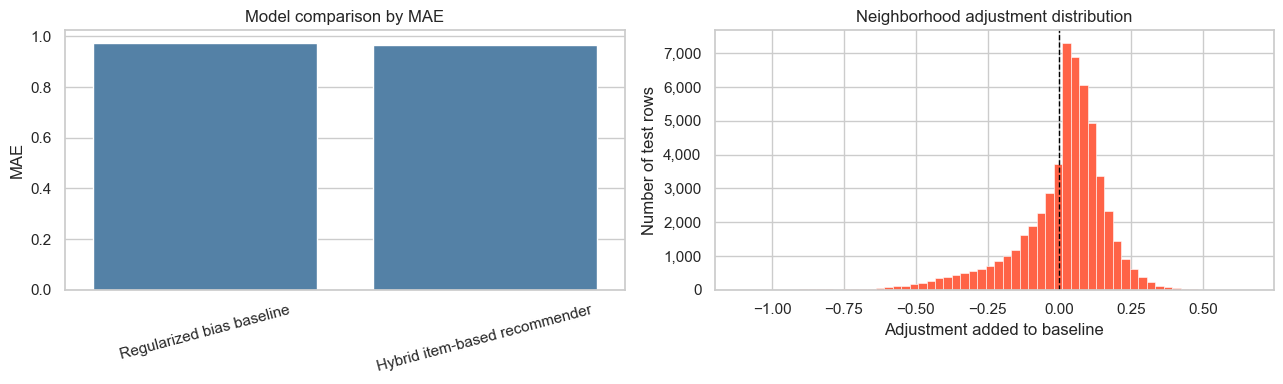

,hybrid_used,test_rows,share_of_test,baseline_MAE,hybrid_MAE,avg_neighbor_count,avg_abs_adjustment
0,False,192337,0.778494,0.999023,0.999023,0.000000,0.000000
1,True,54726,0.221506,0.888996,0.856604,1.902606,0.116083


In [9]:
hybrid_predictions['hybrid_used'] = hybrid_predictions['neighbor_count'] > 0
hybrid_predictions['baseline_error'] = (hybrid_predictions['rating'] - hybrid_predictions['baseline_prediction']).abs()
hybrid_predictions['hybrid_error'] = (hybrid_predictions['rating'] - hybrid_predictions['hybrid_prediction']).abs()

coverage_summary = (
    hybrid_predictions
    .groupby('hybrid_used')
    .agg(
        test_rows=('rating', 'count'),
        share_of_test=('rating', lambda x: len(x) / len(hybrid_predictions)),
        baseline_MAE=('baseline_error', 'mean'),
        hybrid_MAE=('hybrid_error', 'mean'),
        avg_neighbor_count=('neighbor_count', 'mean'),
        avg_abs_adjustment=('neighborhood_adjustment', lambda x: x.abs().mean())
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=model_2_results, x='model', y='MAE', ax=axes[0], color='steelblue')
axes[0].set_title('Model comparison by MAE')
axes[0].set_xlabel('')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].hist(hybrid_predictions.loc[hybrid_predictions['hybrid_used'], 'neighborhood_adjustment'],
             bins=60, color='tomato', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Neighborhood adjustment distribution')
axes[1].set_xlabel('Adjustment added to baseline')
axes[1].set_ylabel('Number of test rows')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

coverage_summary

### Performance by Neighbor Count

This checks whether the hybrid model improves more when it has more related-item evidence.


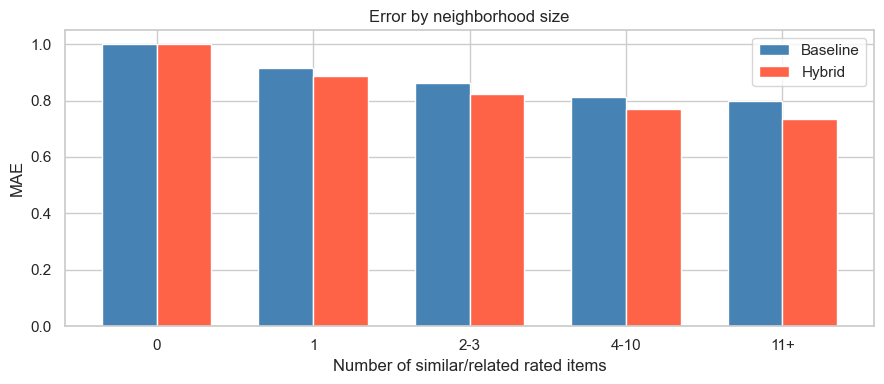

,neighbor_bucket,test_rows,baseline_MAE,hybrid_MAE,avg_neighbor_count
0,0,192337,0.999023,0.999023,0.000000
1,1,34164,0.913713,0.885898,1.000000
2,2-3,14865,0.861813,0.823214,2.291019
3,4-10,5131,0.813152,0.771611,5.357045
4,11+,566,0.798536,0.735809,14.867491


In [10]:
neighbor_eval = hybrid_predictions.copy()
neighbor_eval['neighbor_bucket'] = pd.cut(
    neighbor_eval['neighbor_count'],
    bins=[-1, 0, 1, 3, 10, np.inf],
    labels=['0', '1', '2-3', '4-10', '11+']
)

performance_by_neighbors = (
    neighbor_eval
    .groupby('neighbor_bucket', observed=True)
    .agg(
        test_rows=('rating', 'count'),
        baseline_MAE=('baseline_error', 'mean'),
        hybrid_MAE=('hybrid_error', 'mean'),
        avg_neighbor_count=('neighbor_count', 'mean')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
width = 0.35
x = np.arange(len(performance_by_neighbors))
ax.bar(x - width/2, performance_by_neighbors['baseline_MAE'], width, label='Baseline', color='steelblue')
ax.bar(x + width/2, performance_by_neighbors['hybrid_MAE'], width, label='Hybrid', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(performance_by_neighbors['neighbor_bucket'])
ax.set_xlabel('Number of similar/related rated items')
ax.set_ylabel('MAE')
ax.set_title('Error by neighborhood size')
ax.legend()
plt.tight_layout()
plt.show()

performance_by_neighbors

#### Model 2 Takeaway

The hybrid model improves the baseline when it finds related products the user has rated. The overall improvement is modest because coverage is limited, but the neighbor-count breakdown shows that the related-item signal becomes more useful when more evidence is available.
